In [62]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor 

In [8]:
df = pd.read_excel("energy_efficiency_dataset.xlxs")


In [9]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [12]:
df.columns = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 
    'Overall_Height', 'Orientation', 'Glazing_Area', 
    'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'
]
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [13]:
df.shape

(768, 10)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [21]:
X = df.iloc[:,:-2]
X.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [66]:
y1 = df["Heating_Load"]
y2 = df["Cooling_Load"]

In [121]:
X_train,X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)

X_train, X_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)

model_dict = {
    "Linear" : LinearRegression(),
    "Ridge" : Ridge(),
    "Lasso" : Lasso(alpha=0.1, max_iter=2000),
    "kNeighbours" : KNeighborsRegressor(n_neighbors=7),
    "RandomForest" : RandomForestRegressor(random_state=42,max_depth=10, n_estimators=200),
    "DecisionTree" : DecisionTreeRegressor(max_depth=10,random_state=42),
    "GradientBoosting" : GradientBoostingRegressor(learning_rate=0.05, random_state=42) #1st 0.05, 0.02, 0.1, 0.01

}


In [70]:
X_test.shape


(154, 8)

In [122]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print(f"Train Shape: {X_train_scaled.shape} \n Test Shape: {X_test_scaled.shape}")

Train Shape: (614, 8) 
 Test Shape: (154, 8)


In [ ]:
hl_results = {}

for name, model in model_dict.items():
    model.fit(X_train_scaled,y1_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y1_test, y_pred)
    mae = mean_absolute_error(y1_test, y_pred)
    r2 = r2_score(y1_test, y_pred)

    hl_results[name] = {"MSE": mse, "MAE": mae, "R2": r2}

# Print results in a readable format
for key, value in hl_results.items():
    print(f"{key}: MSE={value['MSE']:.3f}, MAE={value['MAE']:.3f}, R2={value['R2']:.3f}")


Linear: MSE=9.706, MAE=2.257, R2=0.907
Ridge: MSE=9.770, MAE=2.270, R2=0.906
Lasso: MSE=10.498, MAE=2.395, R2=0.899
kNeighbours: MSE=6.726, MAE=1.782, R2=0.935
RandomForest: MSE=9.773, MAE=1.380, R2=0.906
DecisionTree: MSE=50.063, MAE=2.654, R2=0.520
GradientBoosting: MSE=1.947, MAE=0.965, R2=0.981


In [124]:
cl_results = {}

for name, model in model_dict.items():
    model.fit(X_train_scaled,y2_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y2_test, y_pred)
    mae = mean_absolute_error(y2_test, y_pred)
    r2 = r2_score(y2_test, y_pred)

    cl_results[name] = {"MSE": mse, "MAE": mae, "R2": r2}

# Print results in a readable format
for key, value in hl_results.items():
    print(f"{key}: MSE={value['MSE']:.3f}, MAE={value['MAE']:.3f}, R2={value['R2']:.3f}")



Linear: MSE=9.706, MAE=2.257, R2=0.907
Ridge: MSE=9.770, MAE=2.270, R2=0.906
Lasso: MSE=10.498, MAE=2.395, R2=0.899
kNeighbours: MSE=6.726, MAE=1.782, R2=0.935
RandomForest: MSE=9.773, MAE=1.380, R2=0.906
DecisionTree: MSE=50.063, MAE=2.654, R2=0.520
GradientBoosting: MSE=1.947, MAE=0.965, R2=0.981


In [137]:
results = {
    'Heating':hl_results,
    'Cooling':cl_results
}
results_df = pd.DataFrame(results).T

In [138]:
results_df.head()

,Linear,Ridge,Lasso,kNeighbours,RandomForest,DecisionTree,GradientBoosting
Heating,"{'MSE': 9.706183154329853, 'MAE': 2.2573270384...","{'MSE': 9.76974014645013, 'MAE': 2.27017967500...","{'MSE': 10.497509596907067, 'MAE': 2.394973263...","{'MSE': 6.72583563000265, 'MAE': 1.78195547309...","{'MSE': 9.772684467941367, 'MAE': 1.3804591469...","{'MSE': 50.06279803792388, 'MAE': 2.6541661255...","{'MSE': 1.9469569174494747, 'MAE': 0.964602747..."
Cooling,"{'MSE': 10.552985368693957, 'MAE': 2.220929041...","{'MSE': 10.596308570250718, 'MAE': 2.230420560...","{'MSE': 11.409695155212553, 'MAE': 2.371636004...","{'MSE': 7.913860190829576, 'MAE': 2.0221892393...","{'MSE': 10.18936309669468, 'MAE': 2.0924681789...","{'MSE': 48.50394716616603, 'MAE': 3.6212925170...","{'MSE': 8.890876722351107, 'MAE': 1.9836797352..."


In [136]:
results_df.shape


(7, 2)

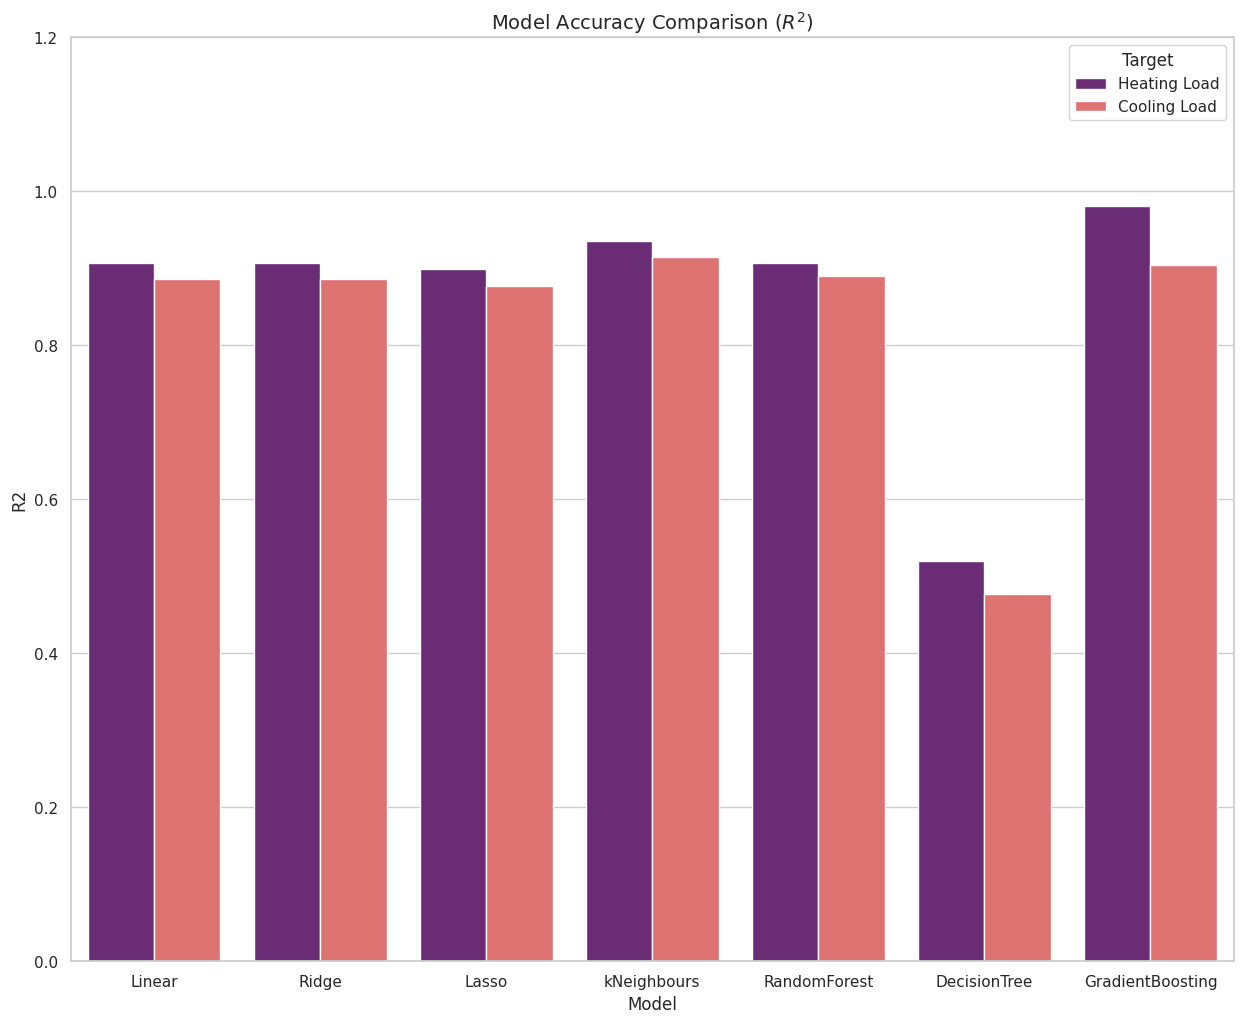

In [144]:
# 1. PREPARE DATA FOR MODEL COMPARISON
df_h = pd.DataFrame(hl_results).T.reset_index().rename(columns={'index':'Model'})
df_h['Target'] = 'Heating Load'
df_c = pd.DataFrame(cl_results).T.reset_index().rename(columns={'index':'Model'})
df_c['Target'] = 'Cooling Load'
comparison_df = pd.concat([df_h, df_c])

# 2. GENERATE BEST MODEL PREDICTIONS (Using Gradient Boosting)
best_model = model_dict['GradientBoosting']
best_model.fit(X_train_scaled, y1_train) # Training on Heating Load as example
y_pred = best_model.predict(X_test_scaled)
residuals = y1_test - y_pred

# --- START PLOTTING ---
fig = plt.figure(figsize=(15, 12))

# PLOT 1: R-Squared Comparison (The "Which Model is Best" Chart)
sns.barplot(data=comparison_df, x='Model', y='R2', hue='Target', palette='magma')
plt.title('Model Accuracy Comparison ($R^2$)', fontsize=14)
plt.ylim(0, 1.2)

plt.show()

Text(0, 0.5, 'Predicted $kWh/m^2$')

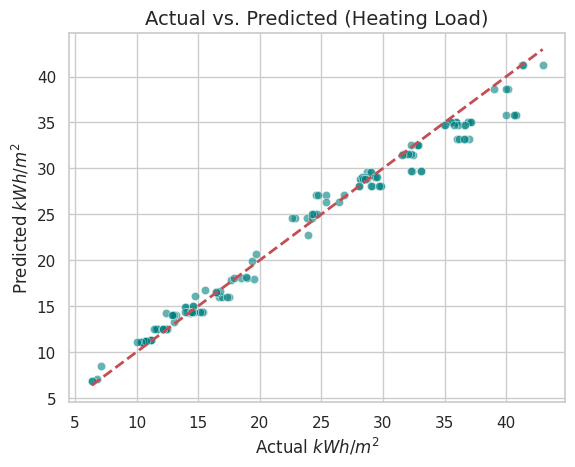

In [145]:
sns.scatterplot(x=y1_test, y=y_pred, alpha=0.6, color='teal')
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted (Heating Load)', fontsize=14)
plt.xlabel('Actual $kWh/m^2$')
plt.ylabel('Predicted $kWh/m^2$')

Text(0, 0.5, 'Residual (Actual - Predicted)')

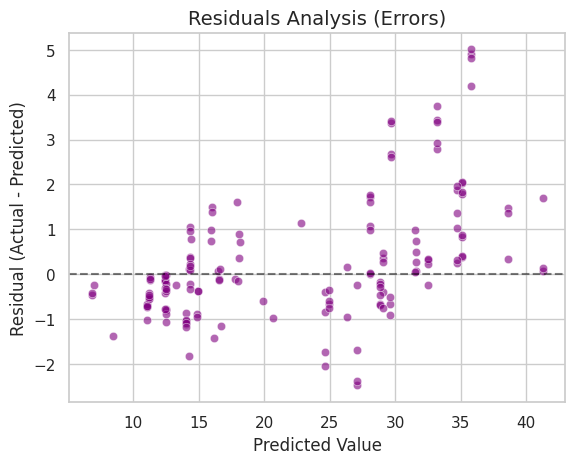

In [146]:
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Residuals Analysis (Errors)', fontsize=14)
plt.xlabel('Predicted Value')
plt.ylabel('Residual (Actual - Predicted)')

/tmp/ipykernel_17936/3276804963.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


Text(0.5, 1.0, 'Feature Importance (Drivers of Load)')

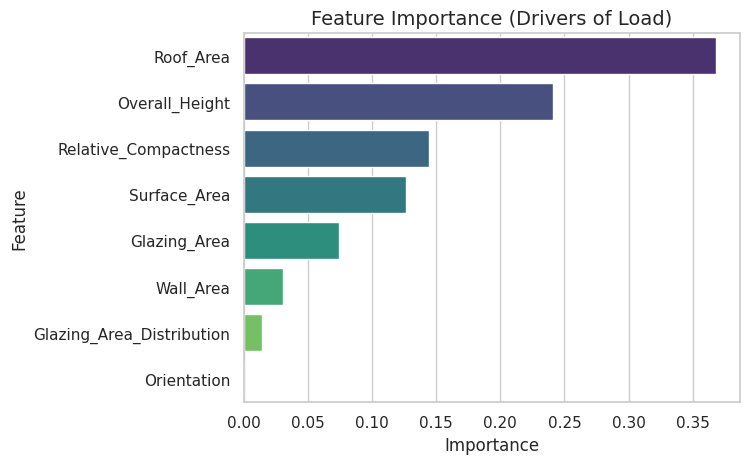

In [150]:
importances = best_model.feature_importances_
df = df.iloc[:,:-2]
feature_names = df.columns # Replace 'X' with your original features dataframe
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Drivers of Load)', fontsize=14)